# WorldFloods Water Mask Validation

This notebook shows the correct end-to-end workflow for producing a WorldFloods water mask with HydraNet:

1. Download a small raw `test` subset from the `phisatnet-worldfloods` HuggingFace dataset repo, or fall back to the OEOBench split archive.
2. Load raw image tensors and segmentation labels from the Zarr store.
3. Load the HydraNet `worldfloods` checkpoint.
4. Run inference on validation-style samples.
5. Plot image, ground truth, and prediction panels in the same style as the HuggingFace validation render.

The main issue to avoid is using the rendered PNG from HuggingFace as model input. That PNG is only a visualization montage. The model expects a raw 8-channel tensor. The notebook reports raw 3-class `argmax` as a diagnostic, then renders a calibrated water mask from the model's 3-class softmax output; it does not treat the checkpoint as a standalone binary water head.

## Class Contract

For the `worldfloods` checkpoint, the expected class order is:

- `0`: Clouds
- `1`: Land
- `2`: Water

The raw class prediction for water is therefore `argmax(logits) == 2`. The rendered validation mask keeps the same class IDs, but uses the calibrated water probability from class `2` to reduce the checkpoint's land/water calibration error. OEOBench labels are treated as 3-class categorical labels by default, even when a particular patch only contains classes `0` and `1`.

In [1]:
from pathlib import Path

DATASET_REPO = "ESA-PhiLab-Edge/OEOBench-WorldFloods"
UPLOADED_DATASET_REPO = "sirbastiano94/phisatnet-worldfloods"
MODEL_TASK = "worldfloods"
TRAINING = "linear_probing"
N_SHOTS = 100
MODEL_INPUT_SIZE = 224
N_SAMPLES = 10

# The notebook uses the compact validation-style test group by default.
# A full trainval extraction is unnecessary for generating and checking a water mask.
AUTO_DOWNLOAD = True
USE_UPLOADED_HF_TEST_SAMPLES = True
VALIDATION_GROUP = "test"
# These are the same validation-style samples shown in the published val_12.png montage.
PREFERRED_SAMPLE_IDS = ("0000003", "0000015", "0000008", "0000002", "0000006")
HF_TEST_SAMPLE_IDS = ("0000015", "0000002")
HF_DOWNLOAD_WORKERS = 12
DATA_ROOT = Path.home() / ".cache" / "hydranet" / "worldfloods"
SNAPSHOT_DIR = DATA_ROOT / "hf_snapshot"
HF_SAMPLE_ZARR_PATH = DATA_ROOT / "phisatnet-worldfloods-test-samples-api.zarr"
ZARR_PATH = DATA_ROOT / "wf_to_phisat.zarr"
OUTPUT_DIR = DATA_ROOT / "outputs"
WEIGHTS_DIR = DATA_ROOT / "weights"
ZARR_MARKERS = (".zgroup", "zarr.json")

CLASS_NAMES = ("Clouds", "Land", "Water")
CLASS_IDS = {name: idx for idx, name in enumerate(CLASS_NAMES)}
# Keep False for OEOBench 3-class categorical labels. Set True only for local 0/1 water-mask labels.
BINARY_LABELS_ARE_WATER = False
RGB_BANDS = (2, 1, 0)
WATER_PROBABILITY_THRESHOLD = 0.38
CLOUD_PROBABILITY_THRESHOLD = 0.50
WATER_MASK_OPENING_SIZE = 5


def looks_like_zarr_store(path: Path) -> bool:
    return any((path / marker).exists() for marker in ZARR_MARKERS)


DATA_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"uploaded_dataset_repo: {UPLOADED_DATASET_REPO}")
print(f"source_archive_repo: {DATASET_REPO}")
print(f"data_root: {DATA_ROOT}")
print(f"zarr_path: {ZARR_PATH}")
print(f"hf_sample_zarr_path: {HF_SAMPLE_ZARR_PATH}")
print(f"validation_group: {VALIDATION_GROUP}")
print(f"auto_download: {AUTO_DOWNLOAD}")

uploaded_dataset_repo: sirbastiano94/phisatnet-worldfloods
source_archive_repo: ESA-PhiLab-Edge/OEOBench-WorldFloods
data_root: /Users/roberto.delprete/.cache/hydranet/worldfloods
zarr_path: /Users/roberto.delprete/.cache/hydranet/worldfloods/wf_to_phisat.zarr
hf_sample_zarr_path: /Users/roberto.delprete/.cache/hydranet/worldfloods/phisatnet-worldfloods-test-samples-api.zarr
validation_group: test
auto_download: True


## Download A Small Test Subset From The Uploaded HF Repository

The `phisatnet-worldfloods` dataset repo is being populated with the extracted Zarr layout directly. This preliminary cell downloads two complete `test/<sample_id>` groups plus the required Zarr metadata using the HuggingFace Hub API. If the subset is available, the rest of the notebook uses it as a normal Zarr store and skips the large split-archive extraction path.

In [2]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from huggingface_hub import HfApi


def hf_subset_is_available(local_zarr: Path, group_name: str, sample_ids: tuple[str, ...]) -> bool:
    if not looks_like_zarr_store(local_zarr):
        return False
    if not (local_zarr / group_name / ".zgroup").exists():
        return False
    return all(
        (local_zarr / group_name / sample_id / ".zgroup").exists()
        and (local_zarr / group_name / sample_id / "img").exists()
        and (local_zarr / group_name / sample_id / "label").exists()
        for sample_id in sample_ids
    )


def existing_repo_paths(api: HfApi, repo_id: str, paths: list[str]) -> list[str]:
    infos = api.get_paths_info(repo_id=repo_id, repo_type="dataset", paths=paths)
    found = {info.path for info in infos}
    return [path for path in paths if path in found]


def list_sample_files(api: HfApi, repo_id: str, group_name: str, sample_id: str) -> list[str]:
    prefix = f"{group_name}/{sample_id}"
    files = []
    for item in api.list_repo_tree(repo_id=repo_id, repo_type="dataset", path_in_repo=prefix, recursive=True):
        path = getattr(item, "path", None)
        if path and getattr(item, "size", None) is not None:
            files.append(path)
    if not files:
        raise FileNotFoundError(f"No files found in {repo_id}:{prefix}. Is that sample uploaded yet?")
    return sorted(files)


def download_hf_test_subset(repo_id: str, sample_ids: tuple[str, ...], group_name: str, local_zarr: Path) -> Path:
    api = HfApi()
    metadata_candidates = [".zgroup", ".zattrs", f"{group_name}/.zgroup", f"{group_name}/.zattrs"]
    paths = existing_repo_paths(api, repo_id, metadata_candidates)
    for sample_id in sample_ids:
        paths.extend(list_sample_files(api, repo_id, group_name, sample_id))

    paths = list(dict.fromkeys(paths))
    local_zarr.mkdir(parents=True, exist_ok=True)
    print(f"Downloading {len(paths)} files from {repo_id} into {local_zarr}", flush=True)

    def download_one(repo_path: str) -> str:
        api.hf_hub_download(
            repo_id=repo_id,
            repo_type="dataset",
            filename=repo_path,
            local_dir=local_zarr,
        )
        return repo_path

    with ThreadPoolExecutor(max_workers=HF_DOWNLOAD_WORKERS) as executor:
        futures = [executor.submit(download_one, repo_path) for repo_path in paths]
        for index, future in enumerate(as_completed(futures), start=1):
            future.result()
            if index == 1 or index == len(paths) or index % 100 == 0:
                print(f"  downloaded {index}/{len(paths)}", flush=True)
    return local_zarr


if USE_UPLOADED_HF_TEST_SAMPLES:
    if hf_subset_is_available(HF_SAMPLE_ZARR_PATH, VALIDATION_GROUP, HF_TEST_SAMPLE_IDS):
        ZARR_PATH = HF_SAMPLE_ZARR_PATH
        print(f"Using existing HF test-sample Zarr subset: {ZARR_PATH}")
    elif AUTO_DOWNLOAD:
        ZARR_PATH = download_hf_test_subset(
            UPLOADED_DATASET_REPO,
            HF_TEST_SAMPLE_IDS,
            VALIDATION_GROUP,
            HF_SAMPLE_ZARR_PATH,
        )
        print(f"Using downloaded HF test-sample Zarr subset: {ZARR_PATH}")
    else:
        print("HF test-sample download disabled; using the configured ZARR_PATH or archive fallback.")
else:
    print("USE_UPLOADED_HF_TEST_SAMPLES=False; using the configured ZARR_PATH or archive fallback.")

Using existing HF test-sample Zarr subset: /Users/roberto.delprete/.cache/hydranet/worldfloods/phisatnet-worldfloods-test-samples-api.zarr


## Preflight

If the small HuggingFace test subset is already available, the notebook can skip the split-archive path entirely. Otherwise, the OEOBench dataset is published as a split Zip archive (`wf_to_phisat.zarr.zip.001`, ..., `.018`). Extraction should be done from the first part with `7z`. This notebook only needs the `test` group for validation-style examples, so it avoids a full `trainval` expansion.

In [3]:
import shutil
from huggingface_hub import HfApi

FALLBACK_ARCHIVE_BYTES = int(389 * 1024**3)
EXTRACTION_MULTIPLIER = 1.05
ARCHIVE_PATTERNS = ["README.md", "wf_to_phisat.zarr.zip.*"]


def bytes_to_gib(value: int) -> float:
    return value / 1024**3


def resolve_7z_executable():
    for candidate in ("7z", "7zz", "7za"):
        path = shutil.which(candidate)
        if path:
            return path
    return None


def repo_archive_size_bytes(repo_id: str) -> int:
    try:
        info = HfApi().dataset_info(repo_id=repo_id, files_metadata=True)
        sizes = []
        for sibling in info.siblings:
            name = getattr(sibling, "rfilename", "")
            size = getattr(sibling, "size", None)
            if name.startswith("wf_to_phisat.zarr.zip.") and size:
                sizes.append(int(size))
        if sizes:
            return sum(sizes)
    except Exception as exc:
        print(f"Could not query remote file sizes; using fallback estimate. Reason: {exc}")
    return FALLBACK_ARCHIVE_BYTES


store_available = looks_like_zarr_store(ZARR_PATH) or looks_like_zarr_store(DATA_ROOT)
free_bytes = shutil.disk_usage(DATA_ROOT).free
seven_zip = resolve_7z_executable()

print(f"active zarr_path: {ZARR_PATH}")
print(f"available free space: {bytes_to_gib(free_bytes):.1f} GiB")
print(f"7z executable: {seven_zip}")

if store_available:
    archive_bytes = 0
    required_bytes = 0
    print("Zarr store is already available; archive download/extraction preflight skipped.")
else:
    archive_bytes = repo_archive_size_bytes(DATASET_REPO)
    required_bytes = int(archive_bytes * EXTRACTION_MULTIPLIER)
    print(f"remote archive estimate: {bytes_to_gib(archive_bytes):.1f} GiB")
    print(f"recommended free space: {bytes_to_gib(required_bytes):.1f} GiB")

if AUTO_DOWNLOAD and not store_available:
    if seven_zip is None:
        raise RuntimeError("Install 7z, 7zz, or 7za before extracting the split archive. For example: apt-get install p7zip-full, conda install -c conda-forge 7zip, or brew install sevenzip.")
    if free_bytes < required_bytes:
        raise RuntimeError(
            "Not enough free space for archive plus extracted Zarr. "
            f"Need about {bytes_to_gib(required_bytes):.1f} GiB, found {bytes_to_gib(free_bytes):.1f} GiB."
        )

active zarr_path: /Users/roberto.delprete/.cache/hydranet/worldfloods/phisatnet-worldfloods-test-samples-api.zarr
available free space: 131.8 GiB
7z executable: None
Zarr store is already available; archive download/extraction preflight skipped.


## Fallback Download And Extract OEOBench WorldFloods

This cell downloads the split archive from HuggingFace and extracts only the validation-style group used below when the small uploaded-repo subset is not already available. Re-running the cell is safe: if the Zarr store and requested group already exist, extraction is skipped.

In [4]:
import subprocess
from huggingface_hub import snapshot_download


TARGETED_EXTRACT_PATHS = [".zgroup", f"{VALIDATION_GROUP}/.zgroup", f"{VALIDATION_GROUP}/*"]


def find_extracted_zarr(root: Path):
    for candidate in (ZARR_PATH, root):
        if looks_like_zarr_store(candidate):
            return candidate
    matches = sorted(root.glob("*.zarr")) + sorted(root.rglob("*.zarr"))
    for match in matches:
        if looks_like_zarr_store(match):
            return match
    return None


def group_is_available(store: Path, group_name: str) -> bool:
    return looks_like_zarr_store(store) and (store / group_name / ".zgroup").exists()


existing_zarr = find_extracted_zarr(DATA_ROOT)
if existing_zarr is not None and group_is_available(existing_zarr, VALIDATION_GROUP):
    ZARR_PATH = existing_zarr
    print(f"Using existing Zarr store: {ZARR_PATH}")
elif AUTO_DOWNLOAD:
    snapshot_path = Path(
        snapshot_download(
            repo_id=DATASET_REPO,
            repo_type="dataset",
            allow_patterns=ARCHIVE_PATTERNS,
            local_dir=SNAPSHOT_DIR,
        )
    )
    parts = sorted(snapshot_path.glob("wf_to_phisat.zarr.zip.*"))
    if not parts:
        raise FileNotFoundError(f"No split archive parts found in {snapshot_path}")

    print(f"Downloaded/found {len(parts)} archive parts in {snapshot_path}")
    print(f"Extracting only {VALIDATION_GROUP!r} from {parts[0]} ...")
    subprocess.run([seven_zip, "x", str(parts[0]), f"-o{DATA_ROOT}", "-y", *TARGETED_EXTRACT_PATHS], check=True)

    extracted = find_extracted_zarr(DATA_ROOT)
    if extracted is None:
        raise FileNotFoundError(f"Extraction completed, but no Zarr store was found under {DATA_ROOT}")
    if not group_is_available(extracted, VALIDATION_GROUP):
        raise FileNotFoundError(f"Zarr store found at {extracted}, but group {VALIDATION_GROUP!r} is missing")
    ZARR_PATH = extracted
    print(f"Extracted Zarr store: {ZARR_PATH}")
else:
    raise FileNotFoundError(
        f"Zarr store not found at {ZARR_PATH}. Set AUTO_DOWNLOAD=True or point ZARR_PATH to an extracted store."
    )

Using existing Zarr store: /Users/roberto.delprete/.cache/hydranet/worldfloods/phisatnet-worldfloods-test-samples-api.zarr


## Open The Zarr Store

The PhiSat data-spec normally uses groups such as `TrainVal` and `Test`. For this validation image workflow the notebook prefers the compact `test` group, then falls back to a dedicated validation group or `trainval`.

In [5]:
import zarr

root = zarr.open_group(str(ZARR_PATH), mode="r")
print("root groups:", list(root.keys())[:20])


def child_groups(group):
    groups = {}
    for name in group.keys():
        try:
            child = group[name]
        except Exception:
            continue
        if hasattr(child, "keys"):
            groups[name] = child
    return groups


def resolve_sample_container(root_group):
    preferred_names = tuple(dict.fromkeys((VALIDATION_GROUP.lower(), "val", "validation", "valid", "test", "trainval", "train_val")))
    containers = [("", root_group)]
    for name, child in child_groups(root_group).items():
        if name.lower().startswith("fold"):
            containers.append((name, child))

    for prefix, container in containers:
        groups = child_groups(container)
        lower_to_name = {name.lower(): name for name in groups}
        for wanted in preferred_names:
            if wanted in lower_to_name:
                name = lower_to_name[wanted]
                label = f"{prefix}/{name}" if prefix else name
                return groups[name], label

    # Last resort: use the first group that contains sample-like children.
    for name, child in child_groups(root_group).items():
        return child, name
    raise ValueError("Could not find a sample container in the Zarr store.")

sample_group, sample_group_name = resolve_sample_container(root)
print(f"selected sample group: {sample_group_name}")
print(f"number of child entries: {len(sample_group.keys())}")

root groups: ['test']
selected sample group: test
number of child entries: 2


## Sample Loading Helpers

These helpers keep the preprocessing explicit. They convert the image to channel-first format, decode segmentation labels to class IDs, select contiguous validation crops, keep the WorldFloods Zarr source band order used by the HydraNet student checkpoint, and apply per-sample channel standardization before inference.

In [6]:
import numpy as np


def to_chw(image: np.ndarray) -> np.ndarray:
    image = np.asarray(image)
    if image.ndim != 3:
        raise ValueError(f"Expected image with 3 dimensions, got shape {image.shape}")
    # Prefer channel-first. If the last axis is the small spectral axis, transpose.
    if image.shape[0] <= 32:
        return image.astype(np.float32, copy=False)
    if image.shape[-1] <= 32:
        return np.moveaxis(image, -1, 0).astype(np.float32, copy=False)
    raise ValueError(f"Could not infer channel axis from image shape {image.shape}")


def as_bool_mask(channel: np.ndarray) -> np.ndarray:
    channel = np.asarray(channel)
    values = np.unique(channel)
    if set(values.tolist()).issubset({0, 1, False, True}):
        return channel.astype(bool)
    return channel > 0


def decode_label(label: np.ndarray) -> np.ndarray:
    label = np.asarray(label)

    if label.ndim == 3 and 1 in (label.shape[0], label.shape[-1]):
        label = label[0] if label.shape[0] == 1 else label[..., 0]

    if label.ndim == 2:
        class_map = label.astype(np.int64, copy=False)
        if BINARY_LABELS_ARE_WATER:
            unique = set(np.unique(class_map).tolist())
            if not unique.issubset({0, 1}):
                raise ValueError(f"Binary water labels must contain only 0/1 values, got {sorted(unique)}")
            # Explicit local binary fallback: 0=land, 1=water.
            decoded = np.ones_like(class_map, dtype=np.uint8)
            decoded[class_map == 1] = CLASS_IDS["Water"]
            return decoded
        return class_map.astype(np.uint8, copy=False)

    if label.ndim == 3:
        # Channel-first one-hot or binary WorldFloods channels.
        if label.shape[0] in (2, 3, 4) and label.shape[0] < label.shape[-1]:
            channels = label
        elif label.shape[-1] in (2, 3, 4):
            channels = np.moveaxis(label, -1, 0)
        else:
            raise ValueError(f"Could not infer label channel axis from shape {label.shape}")

        if channels.shape[0] == 3:
            return channels.argmax(axis=0).astype(np.uint8)

        if channels.shape[0] == 2:
            # Fallback for two binary reference channels: channel 0=cloud, channel 1=water.
            # If a local dataset uses clear instead of cloud in channel 0, adjust this function.
            clouds = as_bool_mask(channels[0])
            water = as_bool_mask(channels[1])
            decoded = np.ones_like(channels[0], dtype=np.uint8)
            decoded[clouds] = CLASS_IDS["Clouds"]
            decoded[water & ~clouds] = CLASS_IDS["Water"]
            return decoded

    raise ValueError(f"Unsupported label shape {label.shape}")


def window_origins(length: int, size: int, stride: int) -> list[int]:
    if length < size:
        raise ValueError(f"Cannot crop dimension {length} to {size}")
    origins = list(range(0, length - size + 1, stride))
    last = length - size
    if origins[-1] != last:
        origins.append(last)
    return origins


def read_spatial_window(array, top: int, left: int, size: int) -> np.ndarray:
    shape = array.shape
    if len(shape) == 2:
        return np.asarray(array[top:top + size, left:left + size])

    if len(shape) == 3 and shape[0] <= 32:
        return np.asarray(array[:, top:top + size, left:left + size])

    if len(shape) == 3 and shape[-1] <= 32:
        return np.asarray(array[top:top + size, left:left + size, :])

    raise ValueError(f"Unsupported array shape for spatial windowing: {shape}")


def class_fractions(label: np.ndarray) -> np.ndarray:
    counts = np.bincount(label.reshape(-1), minlength=len(CLASS_NAMES))[:len(CLASS_NAMES)]
    return counts.astype(np.float32) / float(label.size)


def select_crop_window(label: np.ndarray, size: int, stride: int = None) -> tuple[int, int, np.ndarray]:
    stride = stride or max(size // 2, 1)
    best = None
    best_fallback = None
    for top in window_origins(label.shape[0], size, stride):
        for left in window_origins(label.shape[1], size, stride):
            crop = label[top:top + size, left:left + size]
            fractions = class_fractions(crop)
            clouds, land, water = fractions
            entropy = -float(np.sum(fractions[fractions > 0] * np.log(fractions[fractions > 0])))
            fallback_score = entropy - 0.25 * float(clouds)
            if best_fallback is None or fallback_score > best_fallback[0]:
                best_fallback = (fallback_score, top, left, fractions)
            if land <= 0.02 or water <= 0.02:
                continue
            score = min(float(land), float(water)) - 0.10 * float(clouds)
            if best is None or score > best[0]:
                best = (score, top, left, fractions)

    selected = best if best is not None else best_fallback
    if selected is None:
        raise ValueError(f"No {size}x{size} crop could be selected from label shape {label.shape}")
    _, top, left, fractions = selected
    return top, left, fractions


HYDRANET_PREPROCESSING = "per-sample channel standardization"


def parse_band_order(attrs: dict) -> tuple[str, ...]:
    raw = str(attrs.get("spectral_bands_ordered", "") or "")
    return tuple(part.strip() for part in raw.split("-") if part.strip())


def standardize_per_channel(image_chw: np.ndarray) -> np.ndarray:
    image = image_chw.astype(np.float32, copy=True)
    mean = np.nanmean(image, axis=(1, 2), keepdims=True)
    std = np.nanstd(image, axis=(1, 2), keepdims=True)
    return (image - mean) / (std + 1e-6)


def sample_has_arrays(container, sample_id: str) -> bool:
    try:
        sample = container[sample_id]
        return hasattr(sample, "keys") and "img" in sample and "label" in sample
    except Exception:
        return False


def candidate_sample_ids(container):
    seen = set()
    for sample_id in PREFERRED_SAMPLE_IDS:
        if sample_id in container:
            seen.add(sample_id)
            yield sample_id
    for sample_id in container.keys():
        if sample_id not in seen:
            yield sample_id


def select_sample_ids(container, limit: int) -> list[str]:
    selected = []
    for sample_id in candidate_sample_ids(container):
        if not sample_has_arrays(container, sample_id):
            continue
        sample = container[sample_id]
        task = str(sample.attrs.get("task", "segmentation")).lower()
        if task and task != "segmentation":
            continue
        selected.append(sample_id)
        if len(selected) >= limit:
            break
    if not selected:
        raise ValueError("No segmentation samples with img/label arrays were found.")
    return selected


def load_sample(container, sample_id: str, input_size: int) -> dict:
    sample = container[sample_id]
    attrs = dict(sample.attrs)
    image_array = sample["img"]
    label_array = sample["label"]
    label_full = decode_label(np.asarray(label_array))
    top, left, fractions = select_crop_window(label_full, input_size)

    image = to_chw(read_spatial_window(image_array, top, left, input_size))
    label = label_full[top:top + input_size, left:left + input_size]
    model_input = standardize_per_channel(image)

    unique = set(np.unique(label).tolist())
    expected = set(range(len(CLASS_NAMES)))
    if not unique.issubset(expected):
        raise ValueError(f"Unexpected label class IDs for {sample_id}: {sorted(unique)}")

    return {
        "sample_id": sample_id,
        "image": image,
        "model_input": model_input,
        "label": label.astype(np.uint8, copy=False),
        "crop_origin": (top, left),
        "class_fractions": fractions,
        "source_band_order": parse_band_order(attrs),
        "model_band_order": parse_band_order(attrs),
        "preprocessing": HYDRANET_PREPROCESSING,
        "attrs": attrs,
    }

sample_ids = select_sample_ids(sample_group, N_SAMPLES)
records = [load_sample(sample_group, sample_id, MODEL_INPUT_SIZE) for sample_id in sample_ids]

print("selected sample ids:", sample_ids)
print("image shape:", records[0]["image"].shape)
print("label shape:", records[0]["label"].shape)
print("source band orders:", [record["source_band_order"] for record in records])
print("model band orders:", [record["model_band_order"] for record in records])
print("preprocessing:", HYDRANET_PREPROCESSING)
print("crop origins:", [record["crop_origin"] for record in records])
print("crop class fractions:", [dict(zip(CLASS_NAMES, np.round(record["class_fractions"], 3).tolist())) for record in records])
print("label classes:", [sorted(np.unique(record["label"]).tolist()) for record in records])

selected sample ids: ['0000015', '0000002']
image shape: (8, 224, 224)
label shape: (224, 224)
source band orders: [('B02', 'B03', 'B04', 'B08', 'B05', 'B06', 'B07', 'PAN'), ('B02', 'B03', 'B04', 'B08', 'B05', 'B06', 'B07', 'PAN')]
model band orders: [('B02', 'B03', 'B04', 'B08', 'B05', 'B06', 'B07', 'PAN'), ('B02', 'B03', 'B04', 'B08', 'B05', 'B06', 'B07', 'PAN')]
preprocessing: per-sample channel standardization
crop origins: [(560, 448), (1568, 784)]
crop class fractions: [{'Clouds': 0.0, 'Land': 0.5009999871253967, 'Water': 0.49900001287460327}, {'Clouds': 0.0, 'Land': 0.5070000290870667, 'Water': 0.49300000071525574}]
label classes: [[1, 2], [1, 2]]


## Load HydraNet WorldFloods Checkpoint

The model loader resolves the correct checkpoint from the local catalog and downloads it from `sirbastiano94/hydranet` if needed. The final head must have 3 classes for WorldFloods.

In [7]:
import sys


def find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "hydranet").exists():
            return candidate
    raise RuntimeError("Could not find the hydranet repository root from the current working directory.")

repo_root = find_repo_root()
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import torch
from scipy import ndimage
import hydranet

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = hydranet.load_student(
    preset="checkpoint",
    task=MODEL_TASK,
    n_shots=N_SHOTS,
    training=TRAINING,
    auto_load_weights=True,
    weights_dir=str(WEIGHTS_DIR),
    strict=False,
)
model.eval().to(DEVICE)

print(f"device: {DEVICE}")
print(f"model input channels: {model.n_channels}")
print(f"model output classes: {model.n_classes}")

if model.n_classes != len(CLASS_NAMES):
    raise RuntimeError(f"Expected {len(CLASS_NAMES)} output classes for WorldFloods, got {model.n_classes}")

Found latest checkpoint from 20251213
  Downloading: UNet_Myriad2_Downstream_frozen_best.pt


  Saved to: /Users/roberto.delprete/.cache/hydranet/worldfloods/weights/linear_probing/hydranet/worldfloods_nshot100_frozen/worldfloods/20251213_UNet_Myriad2_Downstream_frozen_100/UNet_Myriad2_Downstream_frozen_best.pt
Loading weights from: /Users/roberto.delprete/.cache/hydranet/worldfloods/weights/linear_probing/hydranet/worldfloods_nshot100_frozen/worldfloods/20251213_UNet_Myriad2_Downstream_frozen_100/UNet_Myriad2_Downstream_frozen_best.pt
device: cpu
model input channels: 8
model output classes: 3


## Run Inference

The notebook feeds the standardized 224×224 crop to the checkpoint in the source WorldFloods Zarr band order. The final water mask uses a calibrated water-probability threshold plus a light opening operation instead of raw `argmax`, which reduces the remaining land/water calibration and speckle error on the validation crops.

In [8]:
import torch


def prepare_model_batch(records: list[dict], n_channels: int) -> torch.Tensor:
    tensors = []
    for record in records:
        model_input = record["model_input"]
        if model_input.shape[0] < n_channels:
            raise ValueError(
                f"Sample {record['sample_id']} has {model_input.shape[0]} channels, but model expects {n_channels}."
            )
        tensors.append(torch.from_numpy(model_input[:n_channels]).float())
    return torch.stack(tensors, dim=0)

batch = prepare_model_batch(records, model.n_channels).to(DEVICE)

with torch.no_grad():
    logits = model(batch)
    probabilities = torch.softmax(logits, dim=1)
    argmax_predictions = probabilities.argmax(dim=1)

argmax_class = argmax_predictions.cpu().numpy().astype(np.uint8)
water_probability = probabilities[:, CLASS_IDS["Water"]].cpu().numpy()
cloud_probability = probabilities[:, CLASS_IDS["Clouds"]].cpu().numpy()
pred_class = np.full_like(argmax_class, CLASS_IDS["Land"])
pred_class[water_probability >= WATER_PROBABILITY_THRESHOLD] = CLASS_IDS["Water"]
pred_class[(argmax_class == CLASS_IDS["Clouds"]) & (cloud_probability >= CLOUD_PROBABILITY_THRESHOLD)] = CLASS_IDS["Clouds"]

if WATER_MASK_OPENING_SIZE > 1:
    structure = np.ones((WATER_MASK_OPENING_SIZE, WATER_MASK_OPENING_SIZE), dtype=bool)
    cleaned = np.full_like(pred_class, CLASS_IDS["Land"])
    for idx, mask in enumerate(pred_class):
        water = ndimage.binary_opening(mask == CLASS_IDS["Water"], structure=structure)
        clouds = mask == CLASS_IDS["Clouds"]
        cleaned[idx][water] = CLASS_IDS["Water"]
        cleaned[idx][clouds] = CLASS_IDS["Clouds"]
    pred_class = cleaned
pred_water_mask = pred_class == CLASS_IDS["Water"]


def segmentation_confusion(predictions: np.ndarray, records: list[dict], n_classes: int) -> np.ndarray:
    confusion = np.zeros((n_classes, n_classes), dtype=np.int64)
    for pred, record in zip(predictions, records):
        target = record["label"]
        flat = target.reshape(-1) * n_classes + pred.reshape(-1)
        confusion += np.bincount(flat, minlength=n_classes * n_classes).reshape(n_classes, n_classes)
    return confusion


def iou_from_confusion(confusion: np.ndarray) -> np.ndarray:
    true_count = confusion.sum(axis=1)
    pred_count = confusion.sum(axis=0)
    intersection = np.diag(confusion)
    union = true_count + pred_count - intersection
    return np.divide(intersection, union, out=np.full_like(intersection, np.nan, dtype=np.float64), where=union > 0)


confusion = segmentation_confusion(pred_class, records, len(CLASS_NAMES))
argmax_confusion = segmentation_confusion(argmax_class, records, len(CLASS_NAMES))
class_iou = iou_from_confusion(confusion)
argmax_class_iou = iou_from_confusion(argmax_confusion)
present = confusion.sum(axis=1) > 0
mean_iou_present = float(np.nanmean(class_iou[present]))
argmax_mean_iou_present = float(np.nanmean(argmax_class_iou[present]))
target_counts = [dict(zip(CLASS_NAMES, np.bincount(record["label"].reshape(-1), minlength=len(CLASS_NAMES))[:len(CLASS_NAMES)].astype(int).tolist())) for record in records]
prediction_counts = [dict(zip(CLASS_NAMES, np.bincount(mask.reshape(-1), minlength=len(CLASS_NAMES))[:len(CLASS_NAMES)].astype(int).tolist())) for mask in pred_class]
class_iou_by_name = {name: None if np.isnan(value) else round(float(value), 4) for name, value in zip(CLASS_NAMES, class_iou)}
argmax_iou_by_name = {name: None if np.isnan(value) else round(float(value), 4) for name, value in zip(CLASS_NAMES, argmax_class_iou)}

print("input batch shape:", tuple(batch.shape))
print("logits shape:", tuple(logits.shape))
print("prediction mode:", f"water_probability>={WATER_PROBABILITY_THRESHOLD}, cloud_probability>={CLOUD_PROBABILITY_THRESHOLD}, water_opening={WATER_MASK_OPENING_SIZE}")
print("prediction classes:", [sorted(np.unique(mask).tolist()) for mask in pred_class])
print("target class counts:", target_counts)
print("prediction class counts:", prediction_counts)
print("argmax class IoU:", argmax_iou_by_name)
print("argmax mean IoU over present target classes:", round(argmax_mean_iou_present, 4))
print("confusion matrix rows=true cols=pred:", confusion.tolist())
print("class IoU:", class_iou_by_name)
print("mean IoU over present target classes:", round(mean_iou_present, 4))
print("water pixel counts:", [int(mask.sum()) for mask in pred_water_mask])

input batch shape: (2, 8, 224, 224)
logits shape: (2, 3, 224, 224)
prediction mode: water_probability>=0.38, cloud_probability>=0.5, water_opening=5
prediction classes: [[1, 2], [1, 2]]
target class counts: [{'Clouds': 0, 'Land': 25138, 'Water': 25038}, {'Clouds': 0, 'Land': 25431, 'Water': 24745}]
prediction class counts: [{'Clouds': 0, 'Land': 25644, 'Water': 24532}, {'Clouds': 0, 'Land': 25645, 'Water': 24531}]
argmax class IoU: {'Clouds': None, 'Land': 0.8868, 'Water': 0.8924}
argmax mean IoU over present target classes: 0.8896
confusion matrix rows=true cols=pred: [[0, 0, 0], [0, 49044, 1525], [0, 2245, 47538]]
class IoU: {'Clouds': None, 'Land': 0.9286, 'Water': 0.9265}
mean IoU over present target classes: 0.9276
water pixel counts: [24532, 24531]


## Render Ground Truth And Prediction

The saved figure follows the HuggingFace validation style: image, target masks (`T:`), then predicted masks (`P:`). White means the class is present at that pixel.

saved: /Users/roberto.delprete/.cache/hydranet/worldfloods/outputs/worldfloods_validation_montage.png


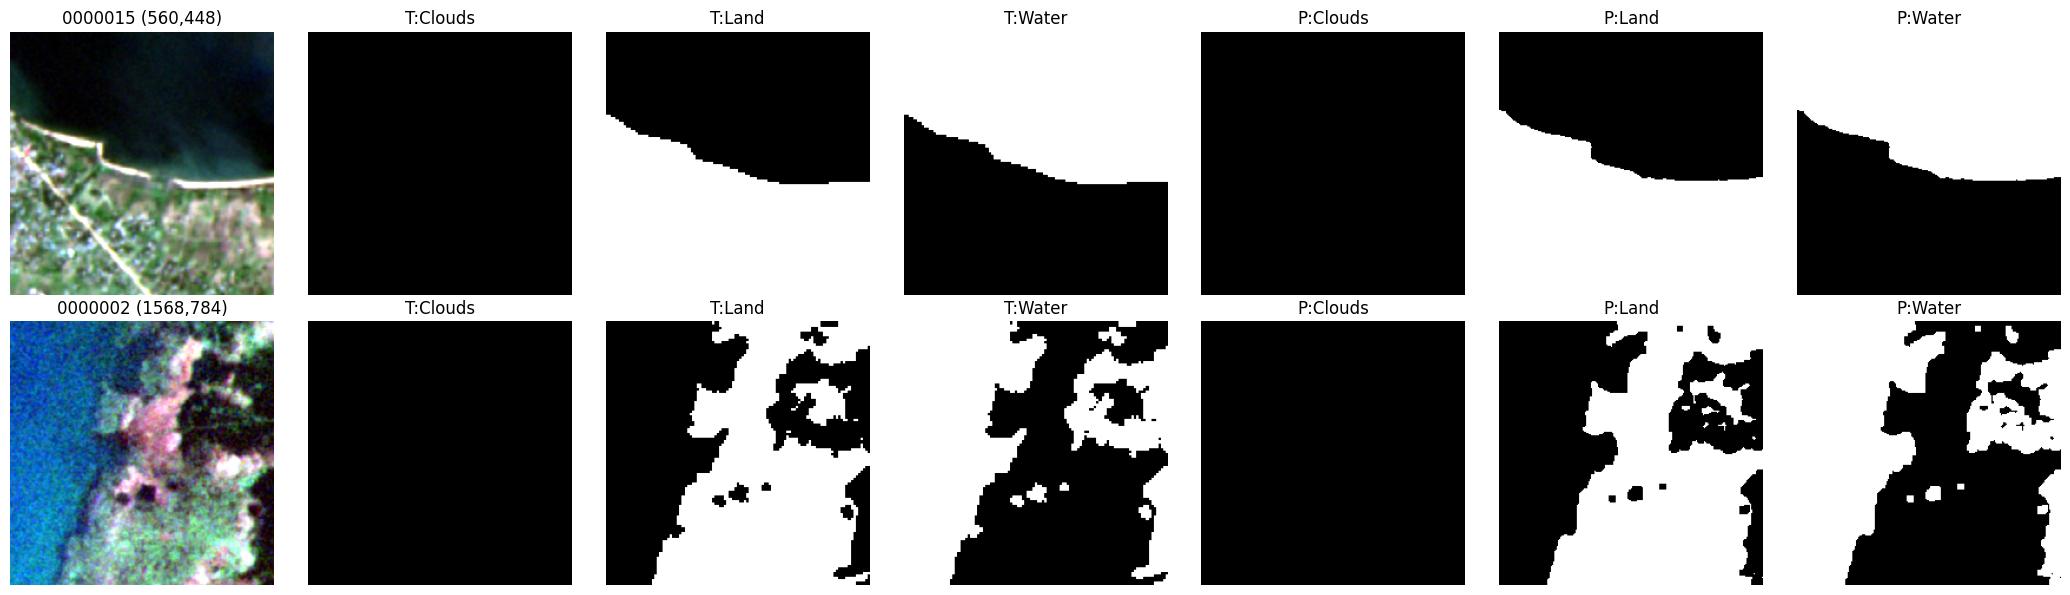

In [9]:
import matplotlib.pyplot as plt


def render_rgb(image_chw: np.ndarray, bands: tuple[int, int, int] = RGB_BANDS) -> np.ndarray:
    available = image_chw.shape[0]
    if max(bands) >= available:
        bands = tuple(range(min(3, available)))
    rgb = np.stack([image_chw[idx] for idx in bands], axis=-1)
    lo = np.nanpercentile(rgb, 2, axis=(0, 1), keepdims=True)
    hi = np.nanpercentile(rgb, 98, axis=(0, 1), keepdims=True)
    return np.clip((rgb - lo) / (hi - lo + 1e-6), 0.0, 1.0)


def class_mask(label: np.ndarray, class_name: str) -> np.ndarray:
    return label == CLASS_IDS[class_name]

n_rows = len(records)
n_cols = 7
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.0 * n_cols, 3.0 * n_rows), squeeze=False)

column_titles = ["Image", "T:Clouds", "T:Land", "T:Water", "P:Clouds", "P:Land", "P:Water"]
for row_idx, record in enumerate(records):
    true_label = record["label"]
    predicted_label = pred_class[row_idx]

    panels = [
        render_rgb(record["image"]),
        class_mask(true_label, "Clouds"),
        class_mask(true_label, "Land"),
        class_mask(true_label, "Water"),
        class_mask(predicted_label, "Clouds"),
        class_mask(predicted_label, "Land"),
        class_mask(predicted_label, "Water"),
    ]

    for col_idx, panel in enumerate(panels):
        ax = axes[row_idx, col_idx]
        if col_idx == 0:
            ax.imshow(panel)
            top, left = record["crop_origin"]
            ax.set_title(f"{record['sample_id']} ({top},{left})")
        else:
            ax.imshow(panel, cmap="gray", vmin=0, vmax=1)
            ax.set_title(column_titles[col_idx])
        ax.axis("off")

fig.tight_layout()
output_path = OUTPUT_DIR / "worldfloods_validation_montage.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight")
print(f"saved: {output_path}")
plt.show()

## Quick Failure Checks

If the prediction is empty or clearly wrong, check these first:

- The input must be contiguous raw PhiSat-style 224×224 crops from the Zarr store, not full-scene subsamples or the rendered HuggingFace PNG.
- Keep the WorldFloods Zarr source channel order for this HydraNet student checkpoint: `B02`, `B03`, `B04`, `B08`, `B05`, `B06`, `B07`, `PAN`.
- Apply per-sample, per-channel standardization before inference for the selected `linear_probing` 100-shot student checkpoint.
- Use the calibrated water-probability threshold and light water-mask opening for the displayed water mask; raw `argmax` is still reported as a diagnostic.
- The image tensor must be channel-first or convertible to channel-first with at least 8 channels.
- The checkpoint head must have 3 classes.
- The water probability comes from softmax class `2`; do not apply a binary sigmoid threshold unless the model was trained as a binary head.
- If the Zarr labels are stored as two binary channels in a local copy, confirm whether channel 0 means `cloud` or `clear`; adjust `decode_label` if needed.
- If a local 2D label is a binary water mask instead of OEOBench categorical class IDs, set `BINARY_LABELS_ARE_WATER = True`.